# Waste Type Identification — Notebook di training (BASELINE)

Baseline a **8 classi** con backbone leggero pre-addestrato (ResNet18) e
CrossEntropy semplice, **senza** contromisure per lo sbilanciamento.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# Percorsi
BASE        = Path('/content/drive/MyDrive/2026_MLinf_gr41/Waste-Project')
DRIVE_DATASET_DIR = BASE / 'dataset'                                            # Sorgente del DataSet sul Drive
DATASET_DIR       = Path('/content/dataset_local')                              # Copia locale del DataSet, per una lettura veloce
SPLIT_CSV   = BASE / 'splits' / 'split.csv'
MODELS_DIR  = BASE / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Iperparametri
IMG_SIZE     = 224
BATCH_SIZE   = 64
NUM_EPOCHS   = 15
LR           = 0.01
MOMENTUM     = 0.9
WEIGHT_DECAY = 1e-4
NUM_CLASSES  = 8
SEED         = 1234

Mounted at /content/drive


In [ ]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from tqdm.auto import tqdm
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, recall_score

# Funzione di utilità per impostare il SEED (per la riproducibilità)
def set_seed(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


## Copia del dataset in locale

Leggere ~15k immagini da Google Drive a ogni epoca è lentissimo (è un filesystem di rete).
Le copiamo **una sola volta** sul disco locale di Colab (`/content`): la copia richiede
qualche minuto, ma poi ogni epoca legge da disco locale ed è molto più veloce, così la
GPU non resta ferma ad aspettare i dati.

In [ ]:
# Funzione di utilità per copiare il DataSet in locale
import shutil, time
if not DATASET_DIR.exists():
    print('Copio il dataset in locale, attendi qualche minuto...')
    t0 = time.time()
    shutil.copytree(DRIVE_DATASET_DIR, DATASET_DIR)
    print(f'Copia completata in {time.time() - t0:.0f}s')
else:
    print('Copia locale gia presente:', DATASET_DIR)

Copia locale gia presente: /content/dataset_local


## Dataset e preprocessing

- **Normalizzazione ImageNet** (il backbone è pre-addestrato lì).
- **Train**: `Resize((224,224))` — riscalamento a quadrato senza crop, così non perdiamo
  contenuto su immagini con aspect ratio molto variabili.
- **Val**: `Resize((224,224))` — riscalamento a quadrato senza crop, così non perdiamo
  contenuto su immagini con aspect ratio molto variabili.

La label usata è quella **macro 0–7** (colonna `label` del CSV), che è ciò su cui
si è valutati.

In [ ]:
CLASS_NAMES = ['battery','clothing','glass','metal','organic','papery','plastic','undifferentiated']
IMAGENET_MEAN = [0.485, 0.456, 0.406]                                           # Media di ImageNet (presa Online)
IMAGENET_STD  = [0.229, 0.224, 0.225]                                           # Deviazione standard di ImageNet (presa Online)

# Trasformazione del Training Set
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Trasformazione del Validation Set
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Classe di comodo per la definizione del DataSet in questione, con le opportune trasformazioni
class WasteDataset(Dataset):
    def __init__(self, csv_path, dataset_dir, split, transform):
        df = pd.read_csv(csv_path)
        self.df = df[df['split'] == split].reset_index(drop=True)
        self.dataset_dir = Path(dataset_dir)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(self.dataset_dir / row['filepath']).convert('RGB')
        return self.transform(img), int(row['label'])

In [ ]:
# Definizione del DataSet di Training e Validation, sfruttando la classe precedentemente creata
train_ds = WasteDataset(SPLIT_CSV, DATASET_DIR, 'train', train_tf)
val_ds   = WasteDataset(SPLIT_CSV, DATASET_DIR, 'val',   val_tf)
print(f'Train: {len(train_ds)}  Val: {len(val_ds)}')

# Definizione dei Loader di entrambi i Set (Training e Validation DataLoader)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True, persistent_workers=True)

Train: 12413  Val: 3102


## Modello, loss, ottimizzatore

Backbone **ResNet18** pre-addestrato su ImageNet, con l'ultimo layer sostituito da
8 uscite. È leggero (~11M parametri), gira ben sotto i limiti di GPU RAM e ha un
buon frame rate — coerente con i criteri di valutazione (accuratezza vs memoria vs velocità).

La loss è **CrossEntropy semplice**: è la baseline.

L'ottimizzatore è **SGD con momentum**, con scheduler a coseno per
ridurre gradualmente il learning rate.

In [ ]:
# Funzione di comodo per la costruzione del modello in questione
# Prende il modello ResNet18 e sostituisce esclusivamente l'ultimo layer (Fine Tuning)
def build_model(num_classes=NUM_CLASSES):
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

model = build_model().to(device)

# Definizione della Loss Function di base: CrossEntropy semplice.
criterion = nn.CrossEntropyLoss()

# Definizione dell'ottimizzatore (SGD) e dello scheduler (Coseno, per ridurre gradualmente il LR).
optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

## Training e validazione

Tracciamo la **balanced accuracy** (media dei TPR delle 8 classi) sia in train sia
in val: è la metrica ufficiale. Salviamo il modello migliore sulla val.

In [ ]:
# Funzione di comodo per eseguire una singola epoca
def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()                     # Se siamo in validation, il gradiente non deve tenere traccia delle operazioni effettuate
    desc = 'train' if train else 'val'
    with ctx:
        for x, y in tqdm(loader, desc=desc, leave=False):
            x, y = x.to(device), y.to(device)
            out = model(x)                                                      # Passo forward (calcolo dell'output)
            loss = criterion(out, y)                                            # Calcolo della Loss
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()        # Se siamo in training, effettuiamo backward e aggiorniamo i pesi della rete
            total_loss += loss.item() * x.size(0)
            all_preds.append(out.argmax(1).cpu())
            all_labels.append(y.cpu())
    preds  = torch.cat(all_preds).numpy()                                       # Vettore contenente tutte le varie predizioni
    labels = torch.cat(all_labels).numpy()                                      # Vettore contenente tutte le varie labels
    return total_loss / len(loader.dataset), balanced_accuracy_score(labels, preds), preds, labels

In [ ]:
# TRAINING vero e proprio

best_bal_acc = 0.0                                                              # Migliore BalancedAccuracy ottenuta
train_losses, val_losses, train_accs, val_accs = [], [], [], []
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_bal, _, _ = run_epoch(model, train_loader, train=True)          # Esegue un'epoca di training e ottiene la rispettiva Loss e BalancedAccuracy (di Training)
    vl_loss, vl_bal, _, _ = run_epoch(model, val_loader,   train=False)         # Esegue un'epoca di validation e ottiene la rispettiva Loss e BalancedAccuracy (di Validation)
    scheduler.step()
    # Stampa dei progressi
    print(f'Epoch {epoch:02d} | train loss {tr_loss:.3f} balAcc {tr_bal:.3f} '
          f'| val loss {vl_loss:.3f} balAcc {vl_bal:.3f}')

    # Memorizza i progressi di questa epoca
    train_losses.append(tr_loss); val_losses.append(vl_loss)
    train_accs.append(tr_bal);   val_accs.append(vl_bal)

    # Se le prestazioni del modello sul validation sono migliorate, salviamo il modello
    if vl_bal > best_bal_acc:
        best_bal_acc = vl_bal
        torch.save(model.state_dict(), MODELS_DIR / 'resnet18_baseline.pth')
        print(f'   -> nuovo best (val balAcc {vl_bal:.3f}) salvato')
print(f'\nBest val balanced accuracy: {best_bal_acc:.3f}')

# Tale baseline è estremamente semplice e serve solamente a capire come performa ResNet18 pre-addestrata con una configurazione standard

train:   0%|          | 0/194 [00:00<?, ?it/s]

val:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 01 | train loss 0.326 balAcc 0.826 | val loss 0.199 balAcc 0.886
   -> nuovo best (val balAcc 0.886) salvato


train:   0%|          | 0/194 [00:00<?, ?it/s]

val:   0%|          | 0/49 [00:00<?, ?it/s]

...

val:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 14 | train loss 0.001 balAcc 1.000 | val loss 0.068 balAcc 0.964


train:   0%|          | 0/194 [00:00<?, ?it/s]

val:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 15 | train loss 0.001 balAcc 0.999 | val loss 0.069 balAcc 0.966

Best val balanced accuracy: 0.967


## Analisi degli errori sulla validation

TPR per classe + matrice di confusione: serve a capire **quali classi** sono deboli
e **con cosa** vengono confuse (es. vetro trasparente ↔ plastica). È il materiale
da cui partono gli esperimenti successivi e la sezione "cosa non ha funzionato" del report.

In [ ]:
# Carica il miglior modello salvato in fase di addestramento
model.load_state_dict(torch.load(MODELS_DIR / 'resnet18_baseline.pth'))

# Esegue un'epoca di Validation con tale modello migliore per valutarne le prestazioni
_, _, preds, labels = run_epoch(model, val_loader, train=False)

# Calcolo del TPR (recall) per classe
print('TPR (recall) per classe:')
rec = recall_score(labels, preds, average=None, labels=list(range(NUM_CLASSES)), zero_division=0)
for i, name in enumerate(CLASS_NAMES):
    print(f'  {name:16s} {rec[i]:.3f}')
print(f'\nBalanced accuracy: {rec.mean():.3f}')                                 # La BalancedAccuracy è banalmente la media dei vari TPR di ciascuna classe

# Calcolo della matrice di confusione
print('\nMatrice di confusione (righe = classi vere, colonne = classi predette):')
cm = confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES)))
print('        ' + ' '.join(f'{i:5d}' for i in range(NUM_CLASSES)))
for i, row in enumerate(cm):
    print(f'{i} {CLASS_NAMES[i][:5]:6s} ' + ' '.join(f'{v:5d}' for v in row))

val:   0%|          | 0/49 [00:00<?, ?it/s]

TPR (recall) per classe:
  battery          0.979
  clothing         0.997
  glass            0.968
  metal            0.955
  organic          0.985
  papery           0.982
  plastic          0.890
  undifferentiated 0.978

Balanced accuracy: 0.967

Matrice di confusione (righe = classi vere, colonne = classi predette):
            0     1     2     3     4     5     6     7
0 batte    185     0     0     1     1     2     0     0
1 cloth      0  1455     2     1     1     0     0     1
2 glass      0     0   389     5     5     0     3     0
3 metal      2     0     3   147     0     0     2     0
4 organ      0     0     1     0   194     1     1     0
5 paper      1     3     0     2     0   381     0     1
6 plast      0     1     8     5     0     3   154     2
7 undif      0     2     0     0     1     0     0   136


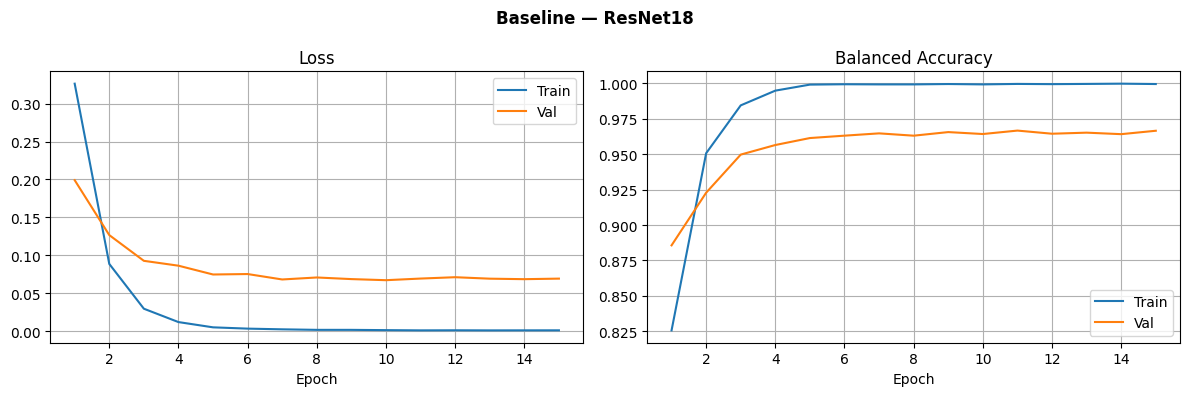

In [ ]:
# Grafico delle metriche Loss e BalancedAccuracy di Training e Validation
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, train_losses, label='Train')
ax1.plot(epochs, val_losses,   label='Val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch')
ax1.legend(); ax1.grid(True)

ax2.plot(epochs, train_accs, label='Train')
ax2.plot(epochs, val_accs,   label='Val')
ax2.set_title('Balanced Accuracy'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(True)

plt.suptitle('Baseline — ResNet18', fontweight='bold')
plt.tight_layout()
plt.savefig(MODELS_DIR / 'baseline_curves.png', dpi=150)
plt.show()